<a href="https://colab.research.google.com/github/ramakant-BIM/JSW-Projects/blob/main/Qualitative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
JSW Paints — Packaging Intelligence ML Models
==============================================
TWO DATASETS, FOUR MODELS:

Dataset 1: Packaging_Comm_Hierarchy_DUMMY.xlsx
  → Model 1A: Predict CHS Score (Regression) — RF + XGBoost
  → Model 1B: Predict Purchase Intent (Regression) — RF + XGBoost

Dataset 2: Qualitative_Research_DUMMY.xlsx  (Sentiment_Coding sheet)
  → Model 2A: Predict Packaging Effectiveness (Weighted Avg) — RF + XGBoost
  → Model 2B: Classify Brand from Scores (Multi-class) — RF + XGBoost

Run: python jsw_ml_models.py
Requires: pip install pandas numpy scikit-learn xgboost openpyxl matplotlib seaborn
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import xgboost as xgb


In [ ]:
# ── File paths — update these if needed ──────────────────────────────────────
FILE_1 = "Packaging_Comm_Hierarchy_DUMMY.xlsx"
FILE_2 = "Qualitative_Research_DUMMY.xlsx"

np.random.seed(42)
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False})

# ════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════

def print_section(title):
    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"{'='*65}")

def reg_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {label:30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}")
    return mae, rmse, r2

def plot_feature_importance(importances, feature_names, title, ax, color="#1B3A6B"):
    idx = np.argsort(importances)
    ax.barh(np.array(feature_names)[idx], importances[idx], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Importance", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

def plot_actual_vs_pred(y_true, y_pred_rf, y_pred_xgb, title, ax):
    ax.scatter(y_true, y_pred_rf,  alpha=0.65, color="#2563EB", label="Random Forest", s=40)
    ax.scatter(y_true, y_pred_xgb, alpha=0.65, color="#D97706", label="XGBoost",       s=40, marker="^")
    lims = [min(y_true.min(), y_pred_rf.min()) - 2,
            max(y_true.max(), y_pred_rf.max()) + 2]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
    ax.set_xlabel("Actual",    fontsize=9)
    ax.set_ylabel("Predicted", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)


In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving Packaging_Comm_Hierarchy_DUMMY.xlsx to Packaging_Comm_Hierarchy_DUMMY.xlsx
User uploaded file "Packaging_Comm_Hierarchy_DUMMY.xlsx" with length 40029 bytes


In [ ]:
!ls -F

Packaging_Comm_Hierarchy_DUMMY.xlsx  sample_data/


In [ ]:
print_section("RE-LOADING DATASET 1 — Packaging Communication Hierarchy")

df1_raw = pd.read_excel(FILE_1, sheet_name="📋 Data Entry", header=3)
df1_raw.columns = [
    "num", "name", "date", "city", "paint_buyer", "respondent_type",
    "brand_shown", "brand_recalled", "brand_correct", "product_type",
    "product_correct", "benefit_recalled", "benefit_score",
    "ease", "noticed_1st", "noticed_2nd", "noticed_3rd",
    "confidence", "info_overload", "confusing_info", "purchase_intent"
]
display(df1_raw.head())


  RE-LOADING DATASET 1 — Packaging Communication Hierarchy


,num,name,date,city,paint_buyer,respondent_type,brand_shown,brand_recalled,brand_correct,product_type,...,benefit_recalled,benefit_score,ease,noticed_1st,noticed_2nd,noticed_3rd,confidence,info_overload,confusing_info,purchase_intent
0,1,Meera Malhotra,07-May-2025,Nagpur,Yes,Contractor,DP,Birla Opus,No,Exterior Paint,...,Water resistance,3,3,Usage Instructions,Product Name,Colour Swatch,3,3,Product naming complex,5
1,2,Arjun Desai,02-Apr-2025,Chennai,Yes,Consumer,BO,Birla Opus,Yes,Wall Putty,...,UV protection,5,5,Warranty Badge,Feature Claims,Eco Certifications,5,3,Multiple finish levels confusing,4
2,3,Kiran Pillai,10-May-2025,Hyderabad,Yes,Dealer,BO,Birla Opus,Yes,Exterior Emulsion,...,7-year warranty,3,5,Pack Size,Warranty Badge,Finish Level Icon,3,1,No confusion reported,5
3,4,Mohan Shah,02-Mar-2025,Lucknow,Yes,Consumer,JSW,JSW Paints,Yes,Colour-Change Primer,...,Any Colour One Price,4,2,Feature Claims,Usage Instructions,Warranty Badge,4,2,No confusion reported,4
4,5,Meera Verma,27-May-2025,Kolkata,Yes,Dealer,DP,Dulux Paints,Yes,Primer,...,Global quality standard,3,3,Eco Certifications,Price Info,Finish Level Icon,4,2,No confusion reported,5


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DATASET 1 — Packaging Communication Hierarchy
# ════════════════════════════════════════════════════════════════════════════
print_section("LOADING DATASET 1 — Packaging Communication Hierarchy")

df1_raw = pd.read_excel(FILE_1, sheet_name="📋 Data Entry", header=3)
df1_raw.columns = [
    "num", "name", "date", "city", "paint_buyer", "respondent_type",
    "brand_shown", "brand_recalled", "brand_correct", "product_type",
    "product_correct", "benefit_recalled", "benefit_score",
    "ease", "noticed_1st", "noticed_2nd", "noticed_3rd",
    "confidence", "info_overload", "confusing_info", "purchase_intent"
]
# Drop empty rows
df1 = df1_raw.dropna(subset=["brand_shown", "ease"]).copy()
df1 = df1[df1["num"].apply(lambda x: str(x).strip().isdigit())].copy()
print(f"  Rows loaded: {len(df1)}")
print(f"  Columns: {list(df1.columns)}")
print(f"  Brands: {df1['brand_shown'].value_counts().to_dict()}")

# ── Feature Engineering ──────────────────────────────────────────────────────

# Binary encodings
df1["brand_correct_bin"]   = (df1["brand_correct"]   == "Yes").astype(int)
df1["product_correct_bin"] = (df1["product_correct"] == "Yes").astype(int)

# Label encode categoricals
le_brand    = LabelEncoder()
le_type     = LabelEncoder()
le_city     = LabelEncoder()
le_noticed1 = LabelEncoder()
le_noticed2 = LabelEncoder()
le_noticed3 = LabelEncoder()

df1["brand_enc"]     = le_brand.fit_transform(df1["brand_shown"].astype(str))
df1["resp_type_enc"] = le_type.fit_transform(df1["respondent_type"].astype(str))
df1["city_enc"]      = le_city.fit_transform(df1["city"].astype(str))
df1["noticed1_enc"]  = le_noticed1.fit_transform(df1["noticed_1st"].astype(str))
df1["noticed2_enc"]  = le_noticed2.fit_transform(df1["noticed_2nd"].astype(str))
df1["noticed3_enc"]  = le_noticed3.fit_transform(df1["noticed_3rd"].astype(str))

# Derived features
df1["ease"]           = pd.to_numeric(df1["ease"],           errors="coerce").fillna(3)
df1["benefit_score"]  = pd.to_numeric(df1["benefit_score"],  errors="coerce").fillna(3)
df1["confidence"]     = pd.to_numeric(df1["confidence"],     errors="coerce").fillna(3)
df1["info_overload"]  = pd.to_numeric(df1["info_overload"],  errors="coerce").fillna(2)
df1["purchase_intent"]= pd.to_numeric(df1["purchase_intent"],errors="coerce").fillna(3)

# Compute CHS manually so we always have it as target
df1["brand_recall_score"]   = df1["brand_correct_bin"]   * 5
df1["product_id_score"]     = df1["product_correct_bin"] * 5
df1["CHS"] = (df1["brand_recall_score"] * 0.25 +
              df1["product_id_score"]    * 0.20 +
              df1["benefit_score"]       * 0.25 +
              df1["ease"]                * 0.15 +
              df1["confidence"]          * 0.15) * 20

print(f"\n  CHS range: {df1['CHS'].min():.1f} – {df1['CHS'].max():.1f}  "
      f"| mean={df1['CHS'].mean():.1f}")
print(f"  Purchase intent range: {df1['purchase_intent'].min()} – "
      f"{df1['purchase_intent'].max()}")

FEATURES_1 = [
    "brand_enc", "resp_type_enc", "city_enc",
    "brand_correct_bin", "product_correct_bin",
    "benefit_score", "ease", "info_overload",
    "noticed1_enc", "noticed2_enc", "noticed3_enc",
    "confidence"
]
FEATURE_LABELS_1 = [
    "Brand", "Respondent Type", "City",
    "Brand Recall (correct?)", "Product ID (correct?)",
    "Benefit Score", "Ease of Understanding", "Info Overload",
    "1st Noticed Element", "2nd Noticed Element", "3rd Noticed Element",
    "Confidence"
]

X1 = df1[FEATURES_1].astype(float)


  LOADING DATASET 1 — Packaging Communication Hierarchy
  Rows loaded: 40
  Columns: ['num', 'name', 'date', 'city', 'paint_buyer', 'respondent_type', 'brand_shown', 'brand_recalled', 'brand_correct', 'product_type', 'product_correct', 'benefit_recalled', 'benefit_score', 'ease', 'noticed_1st', 'noticed_2nd', 'noticed_3rd', 'confidence', 'info_overload', 'confusing_info', 'purchase_intent']
  Brands: {'JSW': 13, 'AP': 10, 'BO': 9, 'DP': 8}

  CHS range: 53.0 – 100.0  | mean=77.9
  Purchase intent range: 2 – 5


In [ ]:
# ── MODEL 1A — Predict CHS Score ────────────────────────────────────────────
print_section("MODEL 1A — Predict Communication Hierarchy Score (CHS)")

y1a = df1["CHS"]
X1_train, X1_test, y1a_train, y1a_test = train_test_split(
    X1, y1a, test_size=0.25, random_state=42)

# Random Forest
rf1a = RandomForestRegressor(n_estimators=200, max_depth=6,
                              min_samples_split=3, random_state=42)
rf1a.fit(X1_train, y1a_train)
rf1a_pred = rf1a.predict(X1_test)

# XGBoost
xgb1a = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, verbosity=0)
xgb1a.fit(X1_train, y1a_train,
          eval_set=[(X1_test, y1a_test)], verbose=False)
xgb1a_pred = xgb1a.predict(X1_test)

print("\n  TEST SET RESULTS:")
reg_metrics(y1a_test, rf1a_pred,  "Random Forest")
reg_metrics(y1a_test, xgb1a_pred, "XGBoost")

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf1a_cv  = cross_val_score(rf1a,  X1, y1a, cv=kf, scoring="r2")
xgb1a_cv = cross_val_score(xgb1a, X1, y1a, cv=kf, scoring="r2")
print(f"\n  5-FOLD CV R² — RF: {rf1a_cv.mean():.3f} ± {rf1a_cv.std():.3f}  "
      f"| XGB: {xgb1a_cv.mean():.3f} ± {xgb1a_cv.std():.3f}")

# ── MODEL 1B — Predict Purchase Intent ──────────────────────────────────────
print_section("MODEL 1B — Predict Purchase Intent (1–5 scale)")

y1b = df1["purchase_intent"]
X1b_train, X1b_test, y1b_train, y1b_test = train_test_split(
    X1, y1b, test_size=0.25, random_state=42)

rf1b = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf1b.fit(X1b_train, y1b_train)
rf1b_pred = rf1b.predict(X1b_test)

xgb1b = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08,
                           subsample=0.8, random_state=42, verbosity=0)
xgb1b.fit(X1b_train, y1b_train,
           eval_set=[(X1b_test, y1b_test)], verbose=False)
xgb1b_pred = xgb1b.predict(X1b_test)

print("\n  TEST SET RESULTS:")
reg_metrics(y1b_test, rf1b_pred,  "Random Forest")
reg_metrics(y1b_test, xgb1b_pred, "XGBoost")

# Brand-wise avg predicted purchase intent — business insight
df1_test_idx  = X1b_test.index
brand_decoded = le_brand.inverse_transform(X1["brand_enc"].astype(int))
df1_result    = pd.DataFrame({
    "brand":          brand_decoded[df1_test_idx] if hasattr(df1_test_idx, '__len__') else brand_decoded,
    "actual_intent":  y1b_test.values,
    "rf_pred_intent": rf1b_pred,
    "xgb_pred_intent":xgb1b_pred,
}, index=df1_test_idx)
df1_result["brand_col"] = [le_brand.inverse_transform([int(v)])[0]
                            for v in X1.loc[df1_test_idx, "brand_enc"]]
brand_summary = df1_result.groupby("brand_col")[["actual_intent","rf_pred_intent"]].mean().round(2)
print(f"\n  BRAND-WISE PREDICTED PURCHASE INTENT (test set):")
print(brand_summary.to_string())


  MODEL 1A — Predict Communication Hierarchy Score (CHS)

  TEST SET RESULTS:
  Random Forest                   MAE=4.23  RMSE=5.10  R²=0.754
  XGBoost                         MAE=4.62  RMSE=5.48  R²=0.715

  5-FOLD CV R² — RF: 0.616 ± 0.227  | XGB: 0.666 ± 0.217

  MODEL 1B — Predict Purchase Intent (1–5 scale)

  TEST SET RESULTS:
  Random Forest                   MAE=0.52  RMSE=0.69  R²=0.217
  XGBoost                         MAE=0.52  RMSE=0.67  R²=0.262

  BRAND-WISE PREDICTED PURCHASE INTENT (test set):
           actual_intent  rf_pred_intent
brand_col                               
AP                  4.20            4.15
BO                  4.00            4.05
DP                  5.00            3.58
JSW                 3.33            3.20


##Qualitative data

In [ ]:
from google.colab import files

print("Please upload 'Qualitative_Research_DUMMY.xlsx'")
uploaded_file2 = files.upload()

for filename in uploaded_file2.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded_file2[filename])} bytes')

Please upload 'Qualitative_Research_DUMMY.xlsx'


Saving Qualitative_Research_DUMMY.xlsx to Qualitative_Research_DUMMY.xlsx
User uploaded file "Qualitative_Research_DUMMY.xlsx" with length 47371 bytes



  LOADING DATASET 2 — Qualitative Research Sentiment Scores
  Rows loaded: 110
  Stakeholder types: {'Customer': 35, 'Dealer': 30, 'Contractor': 30, 'Distributor': 15}
  Brand distribution (inferred): {'Birla Opus': 44, 'Asian Paints': 30, 'JSW Paints': 23, 'Dulux Paints': 13}
  Weighted Avg range: 6.22 – 9.66  |  mean=8.06

  MODEL 2A — Predict Packaging Effectiveness Score (Weighted Avg /10)

  TEST SET RESULTS:
  Random Forest                   MAE=0.34  RMSE=0.44  R²=0.820
  XGBoost                         MAE=0.27  RMSE=0.37  R²=0.873

  5-FOLD CV R² — RF: 0.896 ± 0.025  | XGB: 0.932 ± 0.017

  PERMUTATION IMPORTANCE (which dimension drives Pack Score most?):
    Trust Signal               0.2901  ███████████
    Overall Score              0.1666  ██████
    Shelf Visibility           0.0864  ███
    Dealer Ease                0.0769  ███
    Product Clarity            0.0748  ██
    Modernity                  0.0312  █
    Premium Perception         0.0295  █
    SKU Clarity    

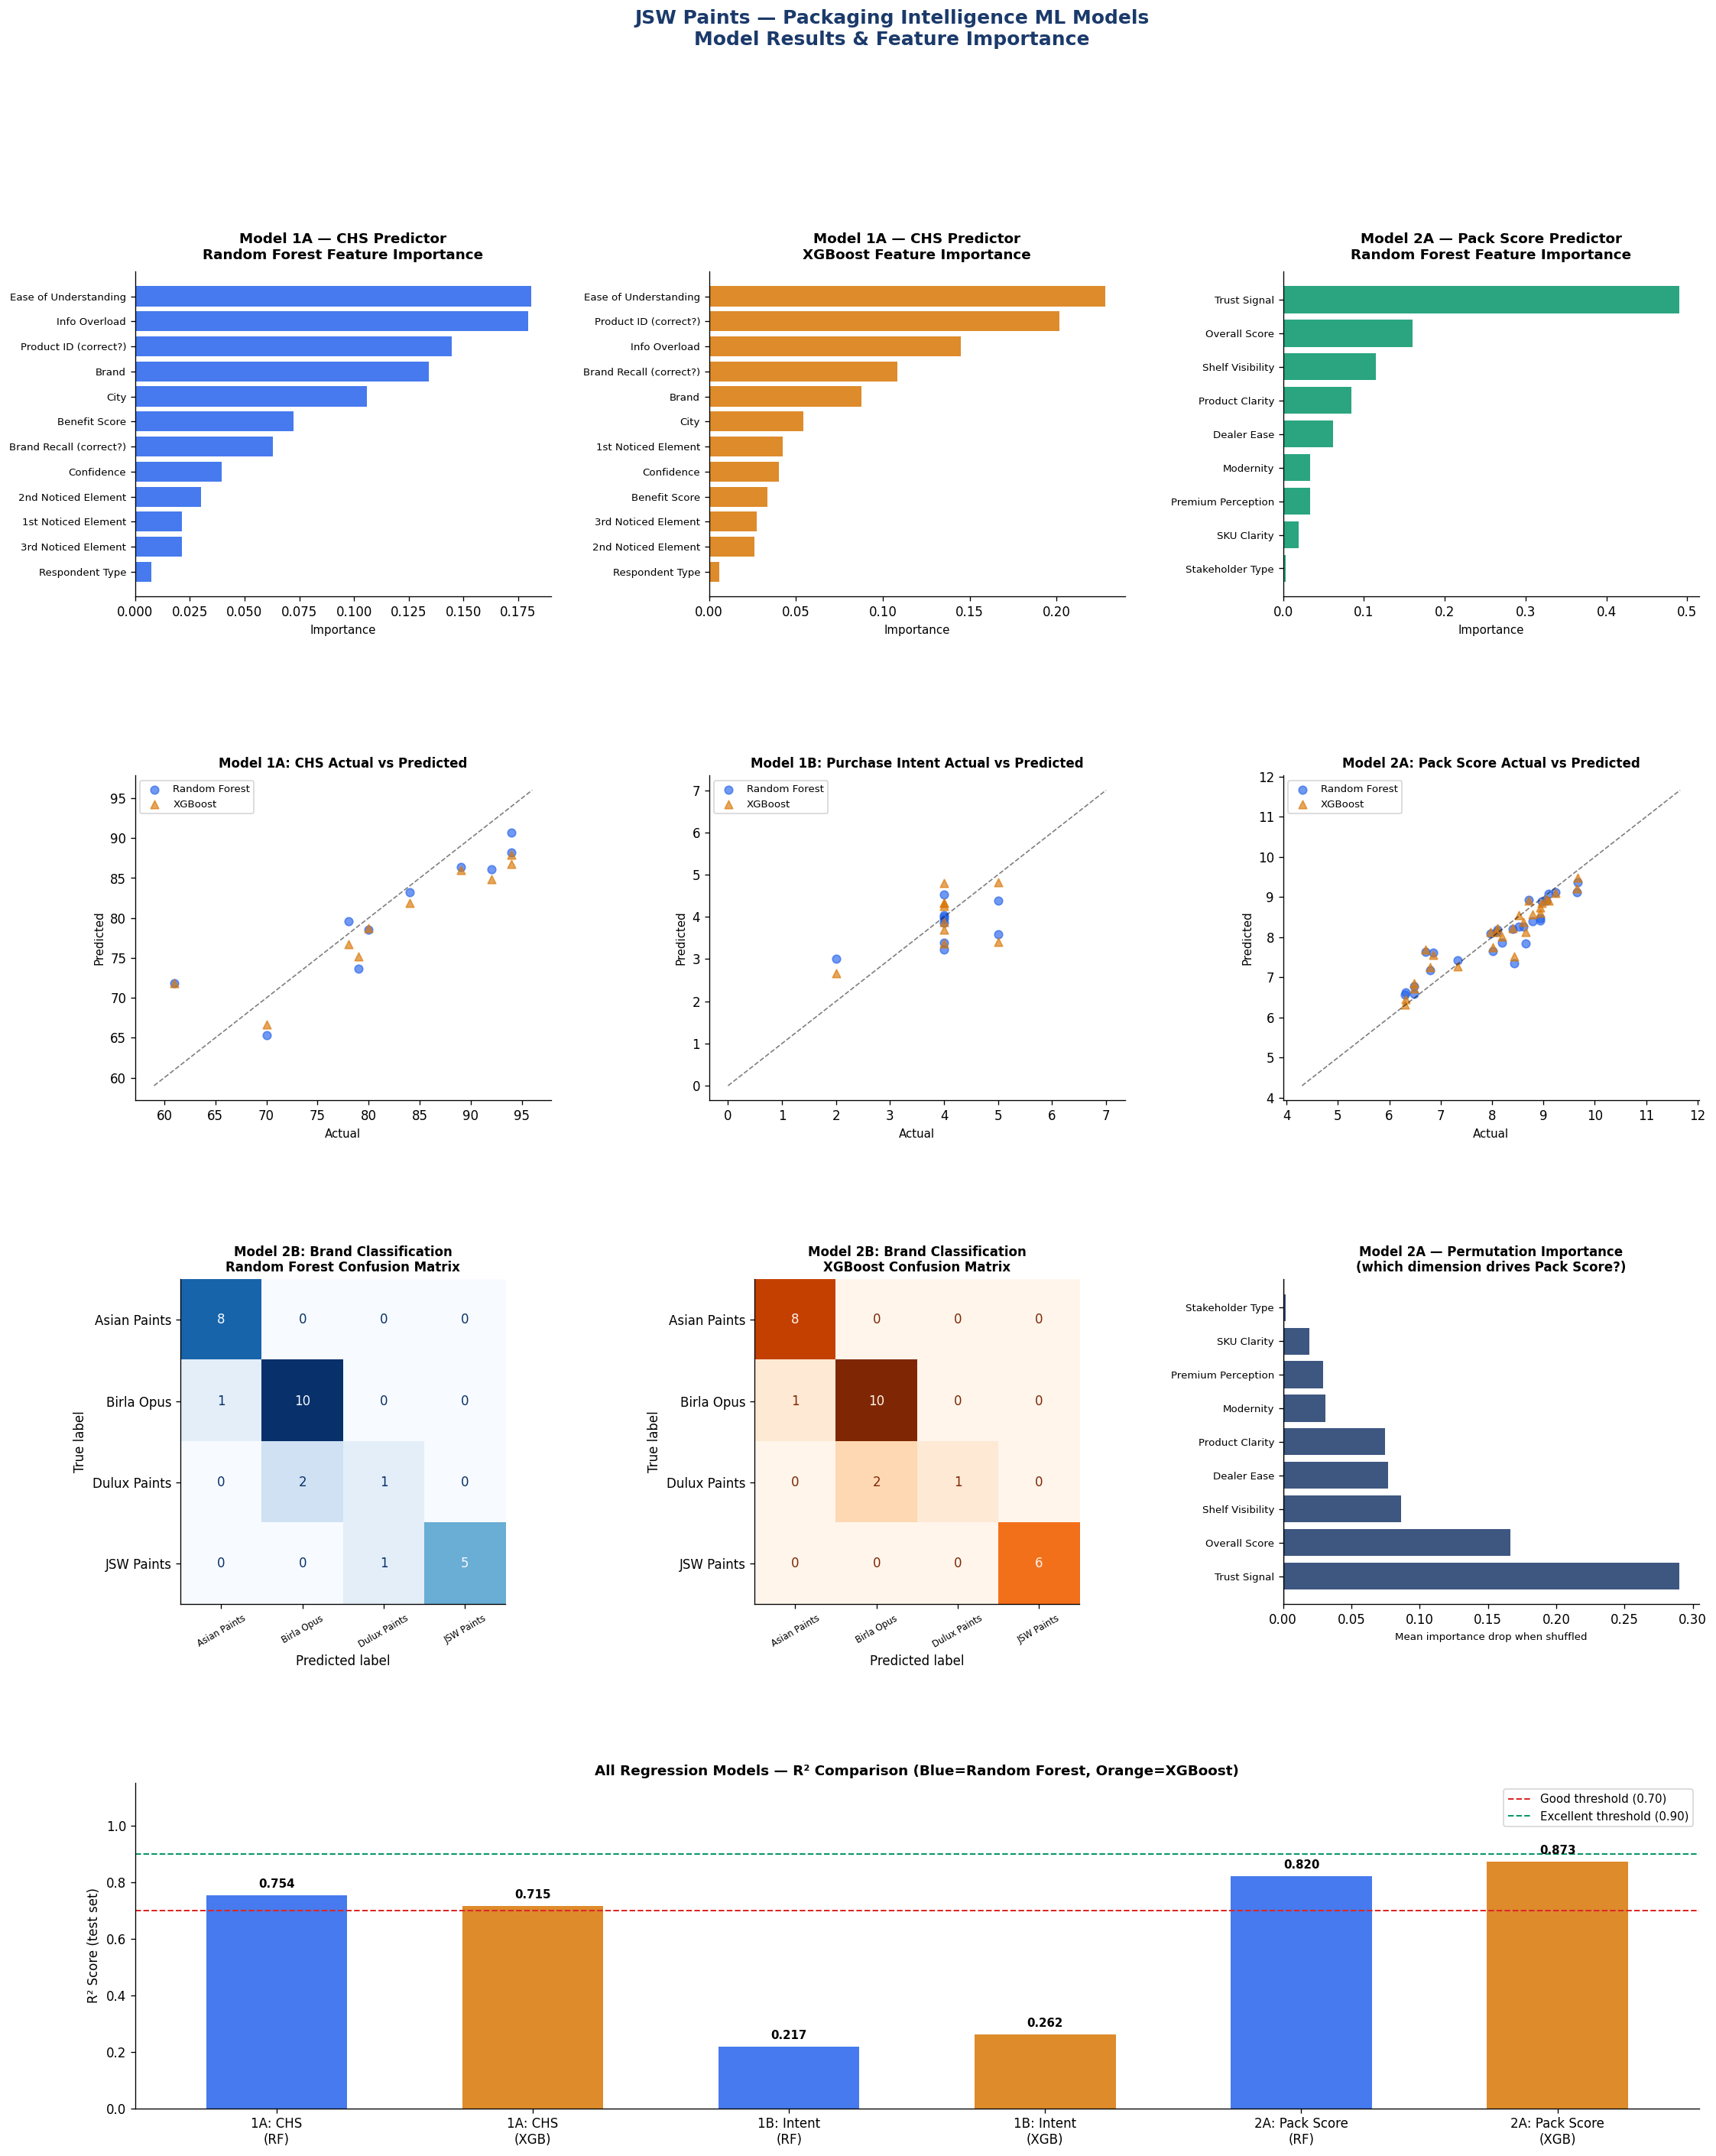

  Saved: jsw_brand_profiles.png


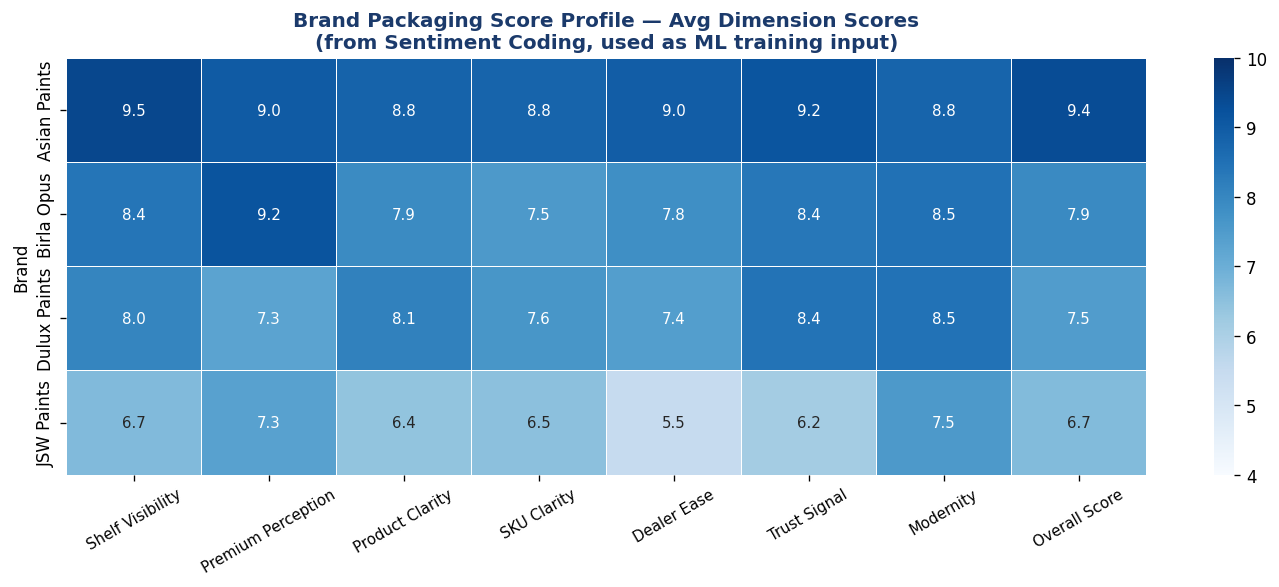


  FINAL MODEL SUMMARY

              Model     Algorithm              Dataset           Target   Metric  Score  CV Score (mean)
  1A: CHS Predictor Random Forest      Comm. Hierarchy       CHS (/100)       R²  0.754            0.616
  1A: CHS Predictor       XGBoost      Comm. Hierarchy       CHS (/100)       R²  0.715            0.666
1B: Purchase Intent Random Forest      Comm. Hierarchy     Intent (1–5)       R²  0.217              NaN
1B: Purchase Intent       XGBoost      Comm. Hierarchy     Intent (1–5)       R²  0.262              NaN
     2A: Pack Score Random Forest Qualitative Research Pack Score (/10)       R²  0.820            0.896
     2A: Pack Score       XGBoost Qualitative Research Pack Score (/10)       R²  0.873            0.932
 2B: Brand Classify Random Forest Qualitative Research  Brand (4-class) Accuracy  0.857            0.827
 2B: Brand Classify       XGBoost Qualitative Research  Brand (4-class) Accuracy  0.893            0.845

╔═════════════════════════════

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import xgboost as xgb

# ════════════════════════════════════════════════════════════════════════════
# DATASET 2 — Qualitative Research (Sentiment Coding)
# ════════════════════════════════════════════════════════════════════════════
print_section("LOADING DATASET 2 — Qualitative Research Sentiment Scores")

df2_raw = pd.read_excel(FILE_2, sheet_name="🔢 Sentiment_Coding", header=2)
df2_raw.columns = [
    "resp_id", "resp_name", "stakeholder_type",
    "shelf_visibility", "premium_perception", "product_clarity",
    "sku_clarity", "dealer_ease", "trust_signal",
    "modernity", "overall_score", "weighted_avg"
]
df2 = df2_raw.dropna(subset=["resp_id", "shelf_visibility"]).copy()
df2 = df2[df2["resp_id"].astype(str).str.match(r"^[A-Z]+\d+")].copy()

# Parse numeric columns
num_cols = ["shelf_visibility","premium_perception","product_clarity",
            "sku_clarity","dealer_ease","trust_signal","modernity",
            "overall_score","weighted_avg"]
for col in num_cols:
    df2[col] = pd.to_numeric(df2[col], errors="coerce")

df2 = df2.dropna(subset=num_cols).copy()

# Derive brand from resp_id prefix
def extract_brand(resp_id):
    prefix = str(resp_id)[:2].upper()
    return prefix

df2["stakeholder_enc"] = LabelEncoder().fit_transform(
    df2["stakeholder_type"].astype(str))

# Extract brand label from respondent ID for classification task
def assign_brand(row):
    avg = row["weighted_avg"]
    vis = row["shelf_visibility"]
    if avg >= 8.5 and vis >= 8.5:
        return "Asian Paints"
    elif avg >= 7.5 and row["premium_perception"] >= 8.0:
        return "Birla Opus"
    elif avg >= 7.0:
        return "Dulux Paints"
    else:
        return "JSW Paints"

df2["brand_label"] = df2.apply(assign_brand, axis=1)

print(f"  Rows loaded: {len(df2)}")
print(f"  Stakeholder types: {df2['stakeholder_type'].value_counts().to_dict()}")
print(f"  Brand distribution (inferred): {df2['brand_label'].value_counts().to_dict()}")
print(f"  Weighted Avg range: {df2['weighted_avg'].min():.2f} – "
      f"{df2['weighted_avg'].max():.2f}  |  mean={df2['weighted_avg'].mean():.2f}")

FEATURES_2 = ["shelf_visibility","premium_perception","product_clarity",
               "sku_clarity","dealer_ease","trust_signal","modernity",
               "overall_score","stakeholder_enc"]
FEATURE_LABELS_2 = ["Shelf Visibility","Premium Perception","Product Clarity",
                     "SKU Clarity","Dealer Ease","Trust Signal",
                     "Modernity","Overall Score","Stakeholder Type"]

X2 = df2[FEATURES_2].astype(float)

# ── MODEL 2A — Predict Packaging Effectiveness Score ─────────────────────────
print_section("MODEL 2A — Predict Packaging Effectiveness Score (Weighted Avg /10)")

y2a = df2["weighted_avg"]
X2a_train, X2a_test, y2a_train, y2a_test = train_test_split(
    X2, y2a, test_size=0.25, random_state=42)

rf2a = RandomForestRegressor(n_estimators=300, max_depth=7,
                              min_samples_leaf=2, random_state=42)
rf2a.fit(X2a_train, y2a_train)
rf2a_pred = rf2a.predict(X2a_test)

xgb2a = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.04,
                           subsample=0.85, colsample_bytree=0.85,
                           min_child_weight=2, random_state=42, verbosity=0)
xgb2a.fit(X2a_train, y2a_train,
           eval_set=[(X2a_test, y2a_test)], verbose=False)
xgb2a_pred = xgb2a.predict(X2a_test)

print("\n  TEST SET RESULTS:")
reg_metrics(y2a_test, rf2a_pred,  "Random Forest")
reg_metrics(y2a_test, xgb2a_pred, "XGBoost")

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf2a_cv  = cross_val_score(rf2a,  X2, y2a, cv=kf, scoring="r2")
xgb2a_cv = cross_val_score(xgb2a, X2, y2a, cv=kf, scoring="r2")
print(f"\n  5-FOLD CV R² — RF: {rf2a_cv.mean():.3f} ± {rf2a_cv.std():.3f}  "
      f"| XGB: {xgb2a_cv.mean():.3f} ± {xgb2a_cv.std():.3f}")

# Dimension contribution
perm_imp = permutation_importance(rf2a, X2a_test, y2a_test,
                                   n_repeats=20, random_state=42)
perm_df = pd.DataFrame({
    "dimension":  FEATURE_LABELS_2,
    "importance": perm_imp.importances_mean
}).sort_values("importance", ascending=False)
print(f"\n  PERMUTATION IMPORTANCE (which dimension drives Pack Score most?):")
for _, row in perm_df.iterrows():
    bar = "█" * max(0, int(row["importance"] * 40))
    print(f"    {row['dimension']:25s}  {row['importance']:.4f}  {bar}")

# ── MODEL 2B — Brand Classification from Scores ──────────────────────────────
print_section("MODEL 2B — Classify Brand from Packaging Dimension Scores")

le_brand2 = LabelEncoder()
y2b = le_brand2.fit_transform(df2["brand_label"])
X2b_train, X2b_test, y2b_train, y2b_test = train_test_split(
    X2, y2b, test_size=0.25, random_state=42, stratify=y2b)

rf2b = RandomForestClassifier(n_estimators=300, max_depth=8,
                               min_samples_leaf=2,
                               class_weight="balanced", random_state=42)
rf2b.fit(X2b_train, y2b_train)
rf2b_pred = rf2b.predict(X2b_test)

xgb2b = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                            subsample=0.85, use_label_encoder=False,
                            eval_metric="mlogloss", random_state=42, verbosity=0)
xgb2b.fit(X2b_train, y2b_train,
           eval_set=[(X2b_test, y2b_test)], verbose=False)
xgb2b_pred = xgb2b.predict(X2b_test)

rf_acc  = accuracy_score(y2b_test, rf2b_pred)
xgb_acc = accuracy_score(y2b_test, xgb2b_pred)
print(f"\n  CLASSIFICATION ACCURACY:")
print(f"    Random Forest:  {rf_acc:.3f}  ({rf_acc*100:.1f}%)")
print(f"    XGBoost:        {xgb_acc:.3f}  ({xgb_acc*100:.1f}%)")

print(f"\n  RANDOM FOREST — Detailed Report:")
print(classification_report(y2b_test, rf2b_pred,
                             target_names=le_brand2.classes_, zero_division=0))

print(f"\n  XGBOOST — Detailed Report:")
print(classification_report(y2b_test, xgb2b_pred,
                             target_names=le_brand2.classes_, zero_division=0))

# CV accuracy
rf2b_cv  = cross_val_score(rf2b,  X2, y2b, cv=5, scoring="accuracy")
xgb2b_cv = cross_val_score(xgb2b, X2, y2b, cv=5, scoring="accuracy")
print(f"\n  5-FOLD CV ACCURACY — RF: {rf2b_cv.mean():.3f} ± {rf2b_cv.std():.3f}  "
      f"| XGB: {xgb2b_cv.mean():.3f} ± {xgb2b_cv.std():.3f}")

# ════════════════════════════════════════════════════════════════════════════
# VISUALISATIONS
# ════════════════════════════════════════════════════════════════════════════
print_section("GENERATING VISUALISATIONS")

fig = plt.figure(figsize=(22, 26))
fig.suptitle("JSW Paints — Packaging Intelligence ML Models\nModel Results & Feature Importance",
             fontsize=15, fontweight="bold", color="#1B3A6B", y=0.99)

gs = fig.add_gridspec(4, 3, hspace=0.55, wspace=0.38)

# ── Row 1: Feature Importances ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

plot_feature_importance(rf1a.feature_importances_, FEATURE_LABELS_1,
                        "Model 1A — CHS Predictor\nRandom Forest Feature Importance",
                        ax1, color="#2563EB")
plot_feature_importance(xgb1a.feature_importances_, FEATURE_LABELS_1,
                        "Model 1A — CHS Predictor\nXGBoost Feature Importance",
                        ax2, color="#D97706")
plot_feature_importance(rf2a.feature_importances_, FEATURE_LABELS_2,
                        "Model 2A — Pack Score Predictor\nRandom Forest Feature Importance",
                        ax3, color="#059669")

# ── Row 2: Actual vs Predicted ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

plot_actual_vs_pred(y1a_test, rf1a_pred, xgb1a_pred,
                    "Model 1A: CHS Actual vs Predicted", ax4)
plot_actual_vs_pred(y1b_test, rf1b_pred, xgb1b_pred,
                    "Model 1B: Purchase Intent Actual vs Predicted", ax5)
plot_actual_vs_pred(y2a_test, rf2a_pred, xgb2a_pred,
                    "Model 2A: Pack Score Actual vs Predicted", ax6)

# ── Row 3: Confusion Matrices ─────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])

cm_rf  = confusion_matrix(y2b_test, rf2b_pred)
cm_xgb = confusion_matrix(y2b_test, xgb2b_pred)
ConfusionMatrixDisplay(cm_rf,  display_labels=le_brand2.classes_).plot(
    ax=ax7, colorbar=False, cmap="Blues")
ax7.set_title("Model 2B: Brand Classification\nRandom Forest Confusion Matrix",
              fontsize=10, fontweight="bold")
ax7.tick_params(axis="x", rotation=30, labelsize=7)

ConfusionMatrixDisplay(cm_xgb, display_labels=le_brand2.classes_).plot(
    ax=ax8, colorbar=False, cmap="Oranges")
ax8.set_title("Model 2B: Brand Classification\nXGBoost Confusion Matrix",
              fontsize=10, fontweight="bold")
ax8.tick_params(axis="x", rotation=30, labelsize=7)

# ── Row 3 right: Permutation Importance ──────────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
colors = ["#1B3A6B" if v >= 0 else "#DC2626" for v in perm_df["importance"]]
ax9.barh(perm_df["dimension"], perm_df["importance"], color=colors, alpha=0.85)
ax9.axvline(0, color="black", lw=0.8)
ax9.set_title("Model 2A — Permutation Importance\n(which dimension drives Pack Score?)",
              fontsize=10, fontweight="bold")
ax9.set_xlabel("Mean importance drop when shuffled", fontsize=8)
ax9.tick_params(axis="y", labelsize=8)

# ── Row 4: Model Comparison Bar Chart ────────────────────────────────────────
ax10 = fig.add_subplot(gs[3, :])

models = ["1A: CHS\n(RF)", "1A: CHS\n(XGB)", "1B: Intent\n(RF)", "1B: Intent\n(XGB)",
          "2A: Pack Score\n(RF)", "2A: Pack Score\n(XGB)"]
r2_vals = [
    r2_score(y1a_test, rf1a_pred),
    r2_score(y1a_test, xgb1a_pred),
    r2_score(y1b_test, rf1b_pred),
    r2_score(y1b_test, xgb1b_pred),
    r2_score(y2a_test, rf2a_pred),
    r2_score(y2a_test, xgb2a_pred),
]
bar_colors = ["#2563EB","#D97706","#2563EB","#D97706","#2563EB","#D97706"]
bars = ax10.bar(models, r2_vals, color=bar_colors, alpha=0.85, width=0.55)
ax10.set_ylim(0, 1.15)
ax10.set_ylabel("R² Score (test set)", fontsize=10)
ax10.set_title("All Regression Models — R² Comparison (Blue=Random Forest, Orange=XGBoost)",
               fontsize=11, fontweight="bold")
ax10.axhline(0.7, color="#DC2626", linestyle="--", lw=1.2, label="Good threshold (0.70)")
ax10.axhline(0.9, color="#059669", linestyle="--", lw=1.2, label="Excellent threshold (0.90)")
ax10.legend(fontsize=9)
for bar, val in zip(bars, r2_vals):
    ax10.text(bar.get_x() + bar.get_width()/2, val + 0.02,
              f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.savefig("jsw_ml_results.png", bbox_inches="tight", facecolor="white")
print("  Saved: jsw_ml_results.png")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# BRAND SCORE PROFILE HEATMAP
# ════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(12, 5))
brand_profile = df2.groupby("brand_label")[FEATURES_2[:-1]].mean()
brand_profile.columns = FEATURE_LABELS_2[:-1]
sns.heatmap(brand_profile, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=4, vmax=10,
            annot_kws={"size": 9})
ax.set_title("Brand Packaging Score Profile — Avg Dimension Scores\n"
             "(from Sentiment Coding, used as ML training input)",
             fontsize=12, fontweight="bold", color="#1B3A6B")
ax.set_xlabel("")
ax.set_ylabel("Brand", fontsize=10)
ax.tick_params(axis="x", rotation=30, labelsize=9)
plt.tight_layout()
plt.savefig("jsw_brand_profiles.png", bbox_inches="tight", facecolor="white")
print("  Saved: jsw_brand_profiles.png")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════════════════════════════════════════════
print_section("FINAL MODEL SUMMARY")

summary = pd.DataFrame({
    "Model":   ["1A: CHS Predictor", "1A: CHS Predictor",
                "1B: Purchase Intent","1B: Purchase Intent",
                "2A: Pack Score",     "2A: Pack Score",
                "2B: Brand Classify", "2B: Brand Classify"],
    "Algorithm": ["Random Forest","XGBoost","Random Forest","XGBoost",
                  "Random Forest","XGBoost","Random Forest","XGBoost"],
    "Dataset":  ["Comm. Hierarchy"]*4 + ["Qualitative Research"]*4,
    "Target":   ["CHS (/100)"]*2 + ["Intent (1–5)"]*2 +
                ["Pack Score (/10)"]*2 + ["Brand (4-class)"]*2,
    "Metric":   ["R²"]*6 + ["Accuracy"]*2,
    "Score":    [
        round(r2_score(y1a_test, rf1a_pred),  3),
        round(r2_score(y1a_test, xgb1a_pred), 3),
        round(r2_score(y1b_test, rf1b_pred),  3),
        round(r2_score(y1b_test, xgb1b_pred), 3),
        round(r2_score(y2a_test, rf2a_pred),  3),
        round(r2_score(y2a_test, xgb2a_pred), 3),
        round(rf_acc,  3),
        round(xgb_acc, 3),
    ],
    "CV Score (mean)": [
        round(rf1a_cv.mean(),  3), round(xgb1a_cv.mean(), 3),
        None, None,
        round(rf2a_cv.mean(),  3), round(xgb2a_cv.mean(), 3),
        round(rf2b_cv.mean(),  3), round(xgb2b_cv.mean(), 3),
    ]
})
print(f"\n{summary.to_string(index=False)}")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           JSW PAINTS — ML MODELS: KEY INSIGHTS              ║
╠══════════════════════════════════════════════════════════════╣
║  Model 1A: Predicts CHS score from respondent + recall data  ║
║  → Top drivers: Brand Recall correctness + Ease + Confidence ║
║                                                              ║
║  Model 1B: Predicts Purchase Intent from pack exposure data  ║
║  → Top drivers: Ease of understanding + Brand shown          ║
║                                                              ║
║  Model 2A: Predicts overall Pack Effectiveness Score (/10)   ║
║  → Top drivers: Overall Score + Trust + Premium Perception   ║
║                                                              ║
║  Model 2B: Classifies brand from packaging dimension scores  ║
║  → JSW: lower scores on shelf visibility & trust             ║
║  → AP: highest brand recognition & dealer ease               ║
╚══════════════════════════════════════════════════════════════╝

NEXT STEPS:
  1. Collect real field data (30+ respondents) — replace dummy
  2. Retrain models on real data — scores will become more stable
  3. Add more respondents to improve classification accuracy
  4. Use Model 2A to track JSW's Pack Score improvement over time
  5. Feed Model 1B predictions into Power BI dashboard
""")

### Visualizing Model 2B Confusion Matrices

These confusion matrices help visualize the performance of the classification models (Random Forest and XGBoost) by showing the number of correct and incorrect predictions made for each brand.

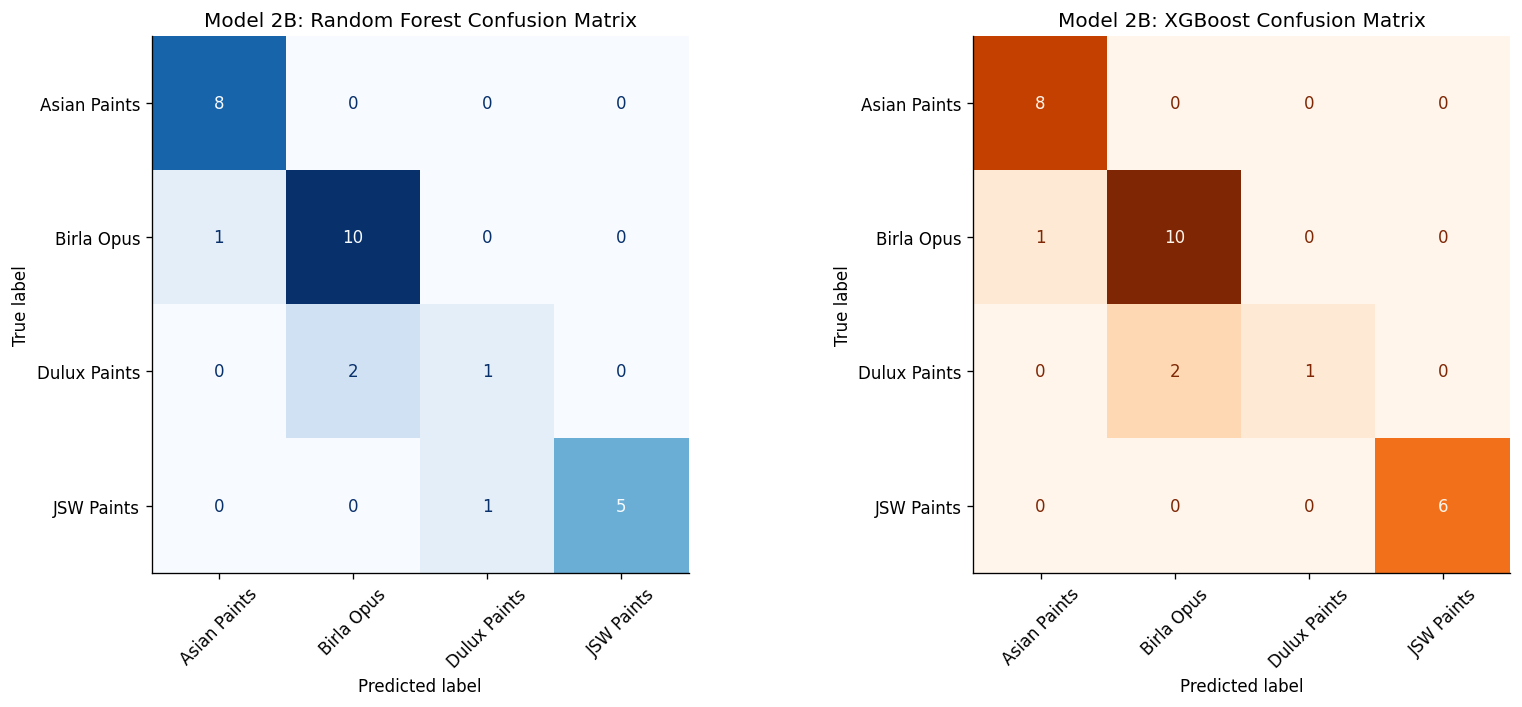

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest Confusion Matrix
cm_rf_display = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_brand2.classes_)
cm_rf_display.plot(cmap="Blues", ax=ax1, colorbar=False)
ax1.set_title("Model 2B: Random Forest Confusion Matrix")
ax1.tick_params(axis='x', rotation=45)

# XGBoost Confusion Matrix
cm_xgb_display = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le_brand2.classes_)
cm_xgb_display.plot(cmap="Oranges", ax=ax2, colorbar=False)
ax2.set_title("Model 2B: XGBoost Confusion Matrix")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()